# 回溯

## 题目目录

- [46-1 全排列](#lc-46)
- [78-3 子集](#lc-78)
- [17-2 电话号码的字母组合](#lc-17)
- [39-5 组合总和](#lc-39)
- [216-7 组合总和 III](#lc-216)
- [22-6 括号生成](#lc-22)
- [131-4 分割回文串](#lc-131)
- [51-8 N 皇后](#lc-51)


## 基础与模板


    nums[:] 在赋值语句的不同位置所起的作用：
    1.在赋值语句左边：原地修改
        如:nums[:] = nums[length-k:]+nums[:length-k]
    2.在赋值语句右边:创建副本
        如:new_nums = nums[:]  # 创建 nums 的完整副本

子集型回溯以及组合型回溯：（时间复杂度等于叶子结点的个数*从根节点到叶子节点的路径长度） 一般来说解的长度是不固定的，使用pop与append，而对于排列型问题而言，可以使用定长的列表


思路一：选或不选

思路二：枚举选哪个（一般使用for循环）

<a id="lc-46"></a>

## 46-1 全排列


### 全排列问题（时间复杂度为O(e*n!)）

在全排列问题当中，始终都是对path这个列表进行处理，如果添加的是path的话只是对原列表的引用，因此当对path进行修改时，也会影响到加入到res当中的列表，正确的做法是添加当前列表的副本

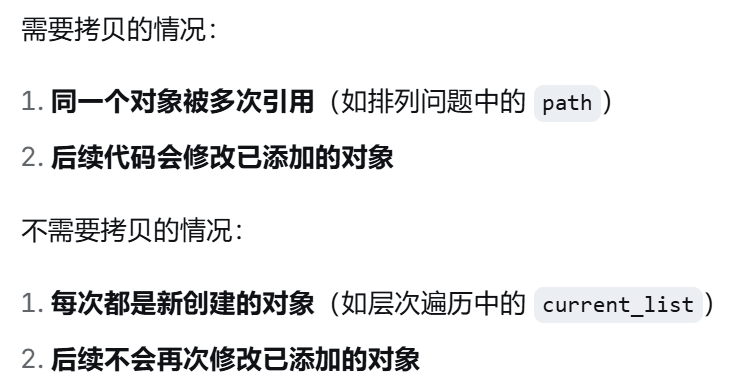


In [ ]:
class Solution(object):
    def permute(self, nums):
        """
        :type nums: List[int]
        :rtype: List[List[int]]
        """
        n = len(nums)
        res = []
        path = [0] * n

        def dfs(i,s):
            if i == n:
                res.append(path[:])
                return
            for j in s:
                path[i] = j
                dfs(i+1,s-{j})#每个数只能选一次，因此选完之后将这个数删除，传入的新的集合不会对原来的集合产生影响

        dfs(0,set(nums))
        return res

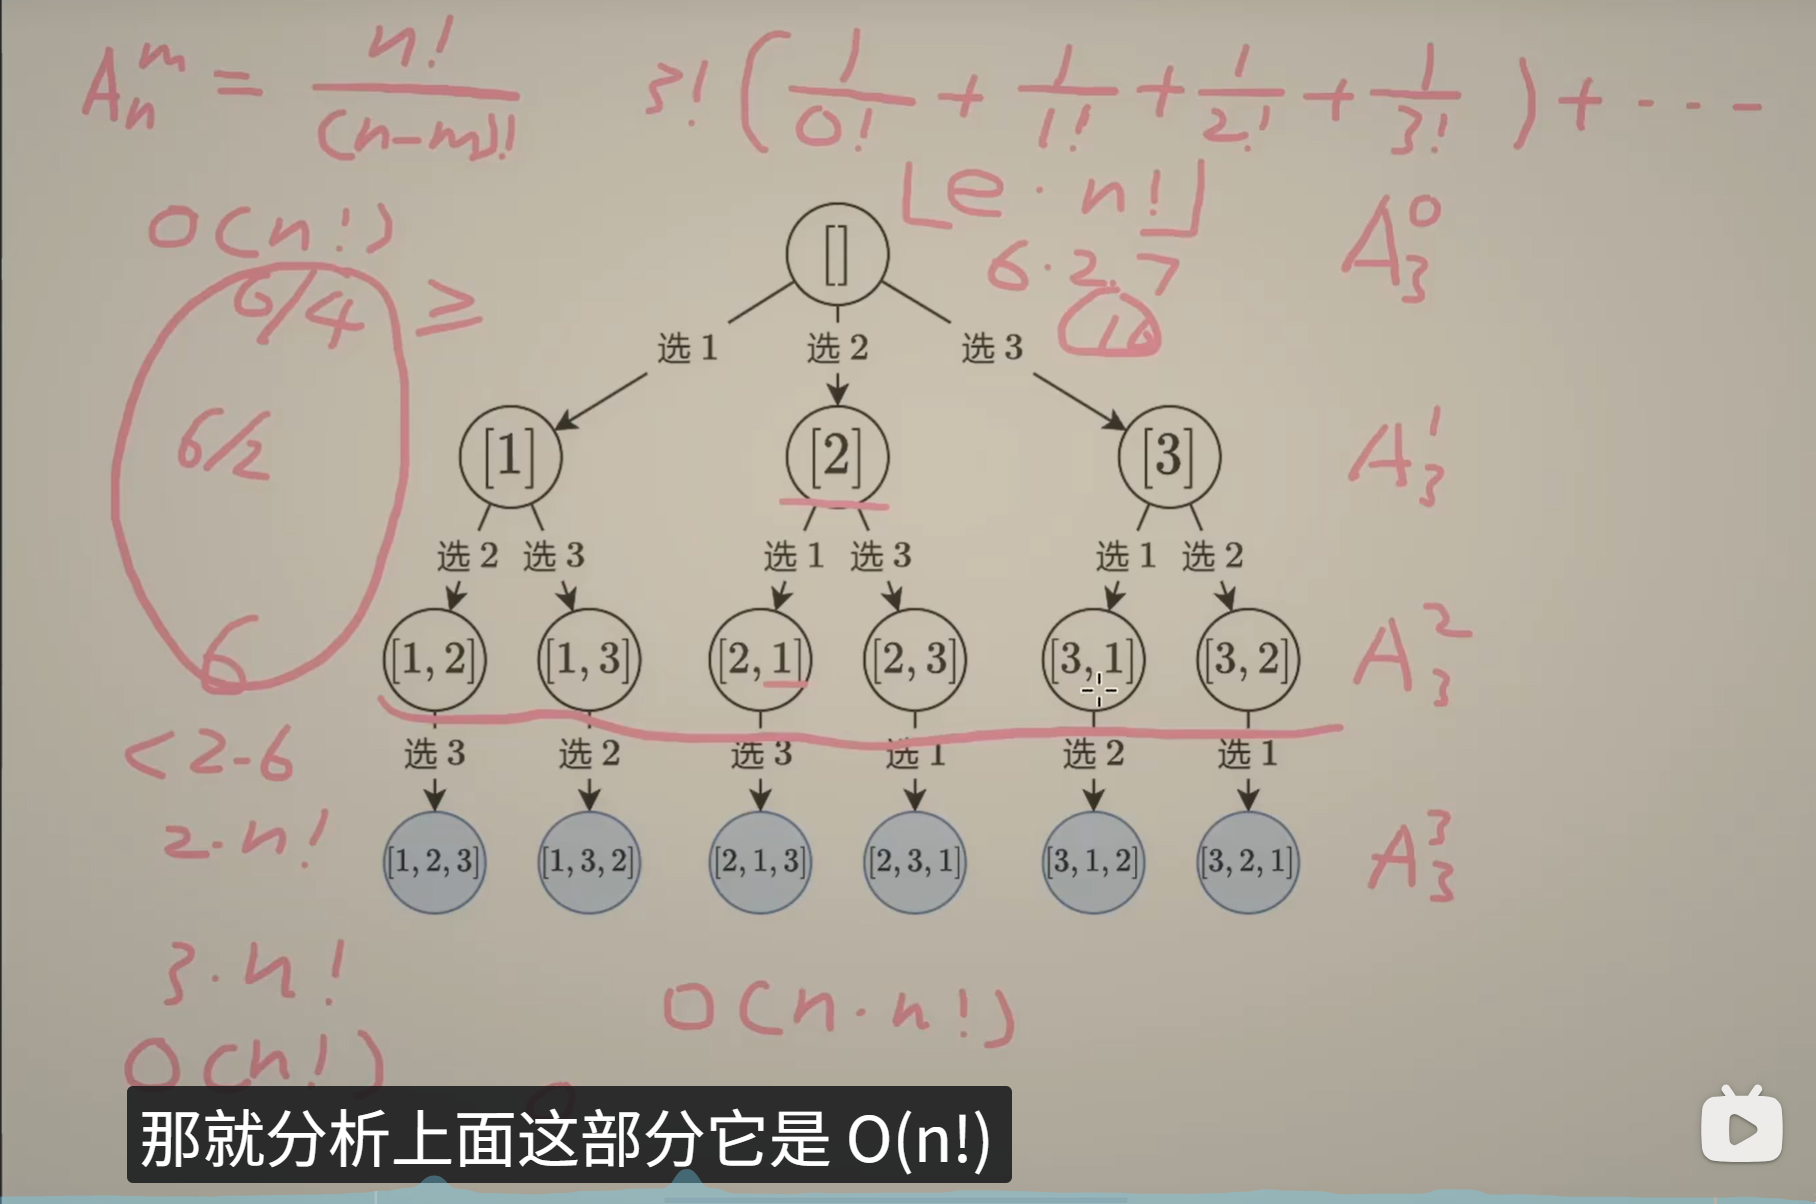


对于全排列问题，分析时间复杂度可以统计结点的数目，对于叶子节点而言为O(n!),叶子节点的上一层节点数为n！，在往上每层最多只有下一层的一半的节点数，因此对于这样的一棵树而言，除叶子节点的节点总数之和最多为(n! + n!/2 + n!/4 + ...)，小于2*n!。再加上最后一层叶子节点的话节点总数为3*n！，使用大O表示法时间复杂度为0(n!),再考虑到res.append(path[:])花费的n的时间，因此时间复杂度为O(n*n!).


<a id="lc-78"></a>

## 78-3 子集


### 子集型


### 模板一：每个数的选与不选

    回溯三问为：
    1.当前的操作是什么：是否选择索引值为i的值并将其加入到path中
    2.子问题是什么：索引值>=i的剩余数的选择问题
    3.下一个子问题：索引值>=i+1的剩余数的选择问题


In [ ]:
class Solution(object):
    def subsets(self, nums):
        """
        :type nums: List[int]
        :rtype: List[List[int]]
        """
        path = []
        res = []
        n  = len(nums)

        def dfs(i):#处理的是大于等于i的部分
            if i == n:#对于选与不选方法，当i等于n的时候，表示对所有字符的选择都已经结束，将结果加入到res中
                res.append(path[:])
                return
            dfs(i+1)

            path.append(nums[i])
            dfs(i+1)
            path.pop()

        dfs(0)
        return res

### 模板二：站在答案的视角，每次必须选一个数

    回溯三问为：
    1.当前操作：枚举一个下标j>=i的数字，加入path
    2.子问题：从>=i的数字中构建子集
    3.下一个子问题：从>=j+1的数字中构建子集


In [ ]:
class Solution(object):
    def subsets(self, nums):
        """
        :type nums: List[int]
        :rtype: List[List[int]]
        """
        path = []
        res = []
        n  = len(nums)

        def dfs(i):#处理的是大于等于i的部分
            res.append(path[:])
            if i == n:
                return

            for j in range(i, n):
                path.append(nums[j])
                dfs(j+1)
                path.pop()

        dfs(0)
        return res

<a id="lc-17"></a>

## 17-2 电话号码的字母组合


### 电话号码的字母组合问题

    对这个题而言，回溯三问为：
    1.当前正在进行的操作是什么：枚举第i个数字的字母（需要使用循环达到枚举的效果）
    2.子问题是什么：构建索引值大于等于i的字符串
    3.下一个子问题是什么：构建索引值大于等于i+1的字符串


In [ ]:
class Solution(object):
    def letterCombinations(self, digits):
        """
        :type digits: str
        :rtype: List[str]
        """
        hashtable = {"2":"abc","3":"def","4":"ghi",
                    "5":"jkl","6":"mno","7":"pqrs",
                     "8":"tuv","9":"wxyz"}
        n = len(digits)
        path = [0] * n
        res = []

        def dfs(i):#i的含义不是第i个，而是大于等于i的部分
            if i == n:#当i等于n的时候，实际的含义是要构建大于等于n的字符串，但字符串的最大索引值为n-1，所以此时构建结束，将结果保存到列表当中
                res.append(''.join(path))
                return
            for x in hashtable[digits[i]]:
                path[i] = x
                dfs(i+1)
        dfs(0)
        return res

<a id="lc-39"></a>

## 39-5 组合总和


### 解题思路

    回溯三问为：
    1.当前操作：从大于等于i的索引中选取一个数，索引为j
    2.子问题：从大于等于索引i的数组中选数加入到总和中看是否等于target
    3.下一个子问题：从大于等于索引j的数组中选数加入到总和中看是否等于target


In [ ]:
class Solution(object):
    def combinationSum(self, candidates, target):
        """
        :type candidates: List[int]
        :type target: int
        :rtype: List[List[int]]
        """
        n = len(candidates)
        path = []
        res = []

        def dfs(i,sum_num):
            if sum_num == target:
                res.append(path[:])
                return
            for j in range(i,n):#使用循环的方法来达到枚举的效果
                if sum_num + candidates[j] <= target:
                    path.append(candidates[j])#此时需要将当前找到的数字加入到原来已找到的数组当中
                    dfs(j,sum_num+candidates[j])
                    path.pop()
        dfs(0,0)
        return res

<a id="lc-216"></a>

## 216-7 组合总和 III


### 组合总和III


In [ ]:
class Solution(object):
    def combinationSum3(self, k, n):
        """
        :type k: int
        :type n: int
        :rtype: List[List[int]]
        """
        path = []
        res = []

        def dfs(i,t):
            d = k - len(path)

            if t < 0 or t > (i + i -d + 1) * d // 2:
                return
            if len(path) == k:#不仅值要相等，还要满足元素的个数相同
                res.append(path[:])
                return
            for j in range(i,d-1,-1):#因为当前还要选d个数，因此必须保证选择的j大于d，小于d的话选不了d个数，从1开始
                path.append(j)
                dfs(j-1,t-j)
                path.pop()

        dfs(9,n)
        return res

<a id="lc-22"></a>

## 22-6 括号生成


### 括号匹配（选与不选问题）


In [ ]:
class Solution(object):
    def generateParenthesis(self, n):
        """
        :type n: int
        :rtype: List[str]
        """
        res = []#
        path = [0] * 2 * n
        left = 0

        def dfs(i,left):
            if i == 2 * n :
                res.append("".join(path[:]))
                return

            if n > left:#能加左括号就加左括号，实在不行在加右括号，选与不选的思路
                path[i] = '('
                dfs(i+1,left+1)
            if i - left < left:
                path[i] = ')'
                dfs(i+1,left)

        dfs(0,0)
        return res

<a id="lc-131"></a>

## 131-4 分割回文串


### 解题思路

    回溯三问为:
    1.当前操作：从索引i开始找一个[i,j]的字符串，判断它是不是回文串
    2.子问题：从当前索引开始查找回文子串（枚举从i开始的字符串）
    3.下一个子问题：从索引j+1开始查找回文串


In [ ]:
class Solution(object):
    def partition(self, s):
        """
        :type s: str
        :rtype: List[List[str]]
        """
        n = len(s)
        res = []
        path = []

        def dfs(i):
            if i == n:
                res.append(path[:])
            for x in range(i,n):
                t = s[i:x+1]#
                if t == t[::-1]:
                    path.append(t)
                    dfs(x+1)
                    path.pop()
        dfs(0)
        return res

<a id="lc-51"></a>

## 51-8 N 皇后


### N皇后问题

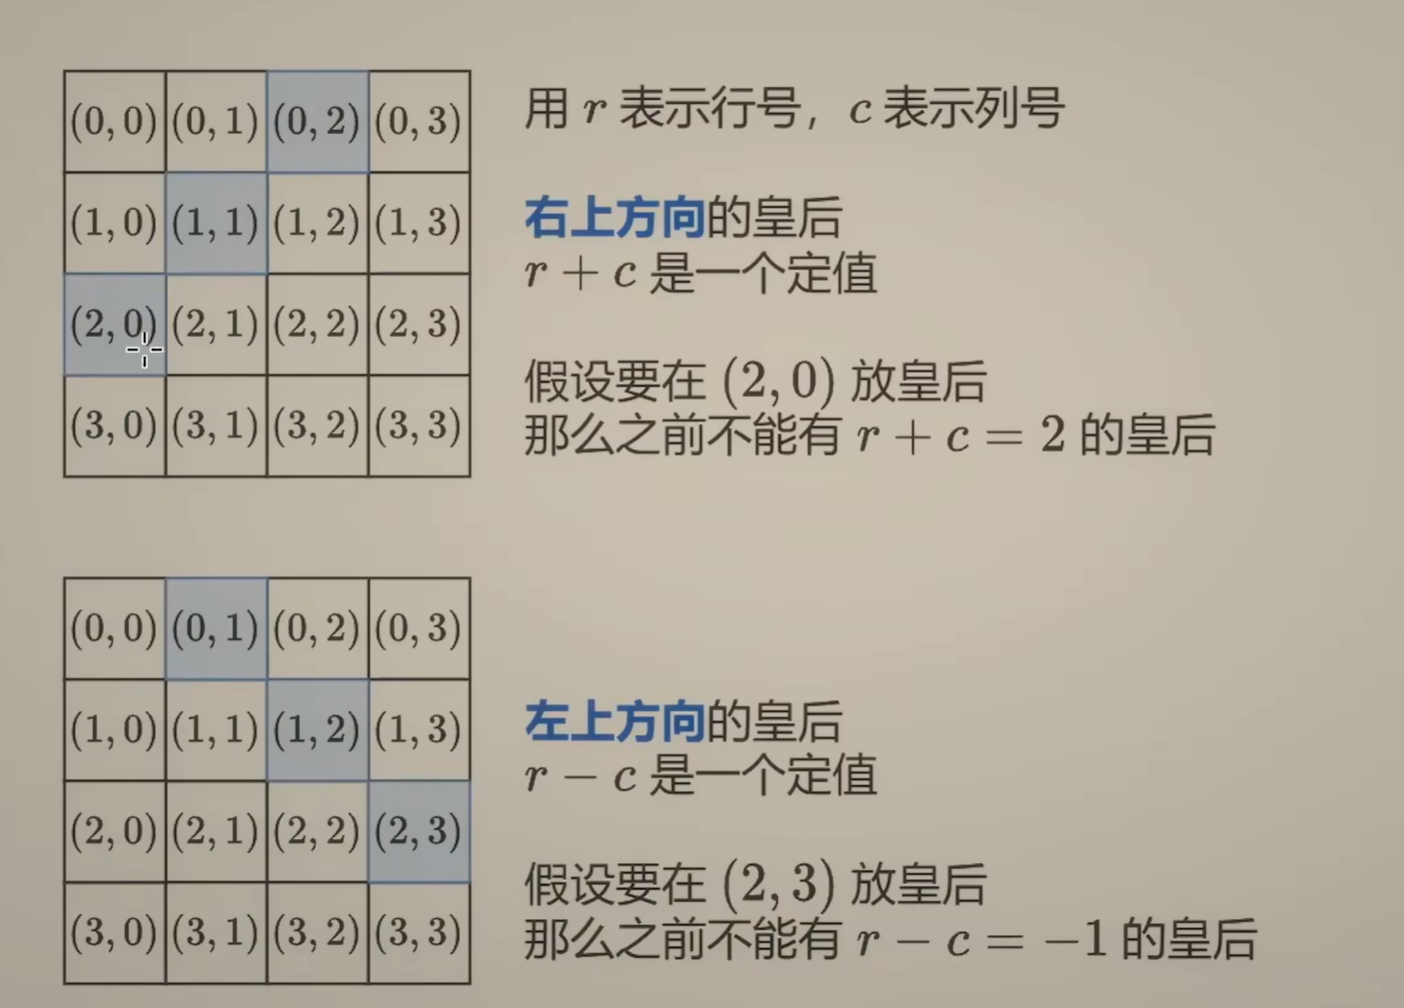


In [ ]:
class Solution(object):
    def solveNQueens(self, n):
        """
        :type n: int
        :rtype: List[List[str]]
        """
        res = []
        col = [0] * n

        def valid(i,j):
            for R in range(i):
                if i+j == R+col[R] or i-j == R-col[R]:
                    return False
            return True

        def dfs(i,s):#代表第i行
            if i == n:
                res.append(['.'*c + 'Q' + '.' * (n-c-1) for c in col])
                return
            for j in s:
                if all( i+j != r+col[r] and i-j != r - col[r] for r in range(i)):#也可以使用all语法来判断
                    col[i] = j#表示第i行的皇后放在第j列
                    dfs(i+1,s-{j})
        dfs(0,set(range(n)))#set(range(n))可以直接生成一个从0到n-1的集合
        return res

In [ ]:
class Solution(object):
    def solveNQueens(self, n):
        m = 2 * n - 1
        res = []
        col = [-1] * n
        on_path = [False] * n#存储的是第j列有没有被访问
        diag1 = [False] * m#对于一个n*n的方格而言，主对角线与副对角线各有2*n-1条，对于同一条主对角线上的元素，满足r-c=常数，而对于副对角线上的元素，满足r+c=常数，常数值作为列表的索引，因此可以通过判断diag1与diag2的元素是否为True判断当前的位置是否与之前的皇后位于同一条对角线上
        diag2 = [False] * m

        def dfs(i):#代表第i行
            if i == n:
                res.append(['.'*c + 'Q' + '.' * (n-c-1) for c in col])#如果在第c列插入皇后，那么这一行前面有c个逗号，后面有n-c-1个逗号
                return
            for j in range(n):
                if not on_path[j] and not diag1[i+j] and not diag2[i-j]:#因为没有使用循环，速度更快
                    col[i] = j
                    on_path[j] = diag1[i+j] = diag2[i-j] = True
                    dfs(i+1)
                    on_path[j] = diag1[i+j] = diag2[i-j] = False
        dfs(0)
        return res